In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

In [2]:
%pip install psycopg2

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

load_dotenv('../.env')

# Connect to the database
engine = create_engine(os.getenv("DATABASE_URL"))

# Load data into a Pandas DataFrame
print("Fetching data from PostgreSQL...")

query = "SELECT * FROM transactions"
df = pd.read_sql(query, engine)

# Ensure datetime format and calculate total sales
df['invoice_date'] = pd.to_datetime(df['invoice_date'])
df['total_sales'] = df['quantity'] * df['unit_price']

print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()

Fetching data from PostgreSQL...
Loaded 397885 rows and 10 columns.


,id,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,total_sales
0,1,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,2,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,3,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,4,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,5,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


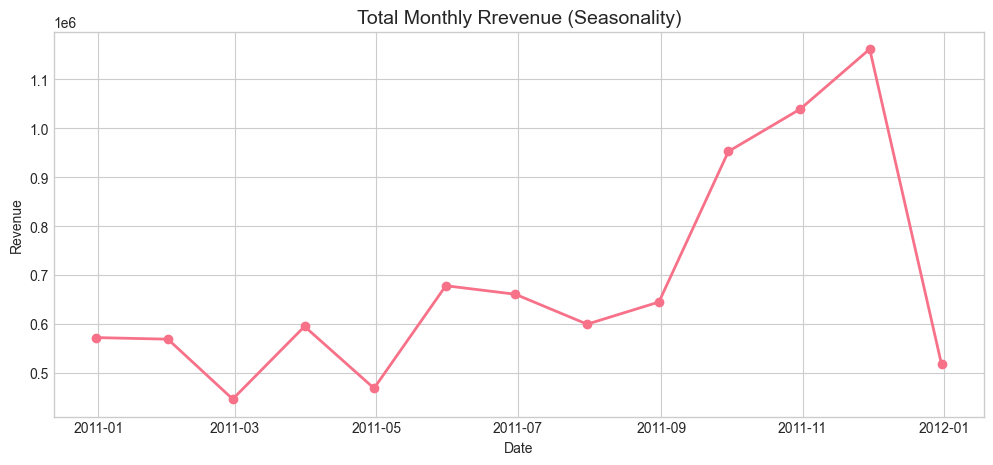

In [5]:
monthly_sales = df.set_index('invoice_date').resample('ME')['total_sales'].sum()
plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker = 'o', linewidth = 2)
plt.title('Total Monthly Rrevenue (Seasonality)', fontsize = 14)
plt.ylabel('Revenue')
plt.xlabel('Date')
plt.show()


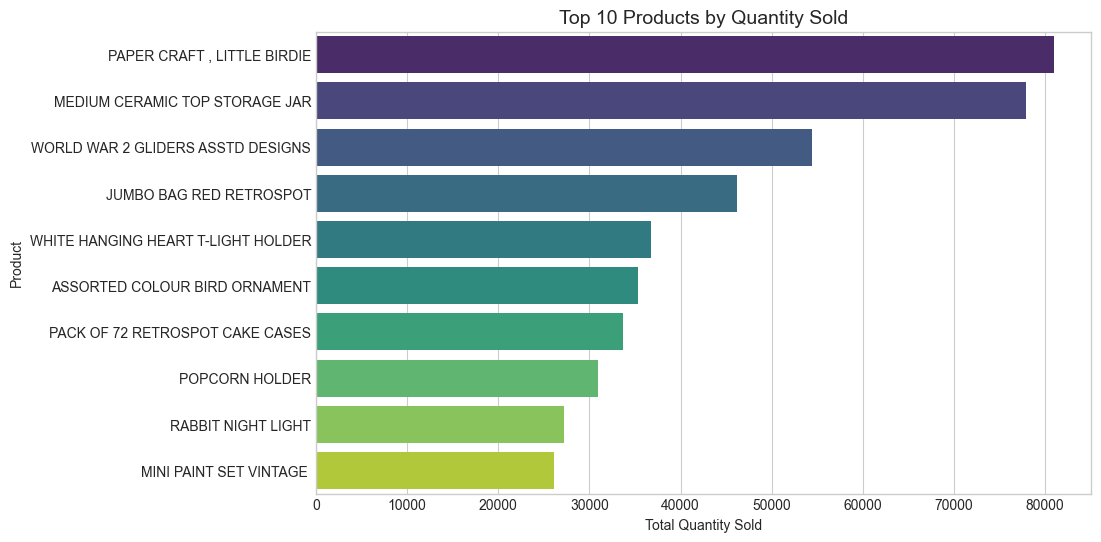

In [10]:
top_skus = df.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_skus.values, y=top_skus.index, palette="viridis", hue = top_skus.index)
plt.title('Top 10 Products by Quantity Sold', fontsize=14)
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.show()

In [11]:
# 1. Keeping only the top 100 selling items (to remove noise from rare items)
top_100_skus = df.groupby('stock_code')['quantity'].sum().nlargest(100).index
df_top = df[df['stock_code'].isin(top_100_skus)].copy()

# 2. Aggregate data to Weekly level per SKU
# 'W' stands for weekly frequency
weekly_demand = df_top.groupby([pd.Grouper(key='invoice_date', freq='W'), 'stock_code'])['quantity'].sum().reset_index()
weekly_demand = weekly_demand.rename(columns={'quantity': 'weekly_sales', 'invoice_date': 'week'})

# Sort by SKU and Date to ensure time-series order
weekly_demand = weekly_demand.sort_values(by=['stock_code', 'week']).reset_index(drop=True)

# 3. Engineer Lag Features (What were the sales 1 week ago? 2 weeks ago?)
weekly_demand['lag_1_week'] = weekly_demand.groupby('stock_code')['weekly_sales'].shift(1)
weekly_demand['lag_2_week'] = weekly_demand.groupby('stock_code')['weekly_sales'].shift(2)

# 4. Engineer Rolling Averages (What is the 4-week moving average trend?)
weekly_demand['rolling_4_wk_avg'] = weekly_demand.groupby('stock_code')['lag_1_week'].transform(
    lambda x: x.rolling(window=4, min_periods=1).mean()
)

# 5. Time-based categorical features
weekly_demand['month'] = weekly_demand['week'].dt.month

# Drop the rows with NaN values created by the shifting/lagging process
final_features = weekly_demand.dropna().copy()

print(f"Engineered dataset ready! Shape: {final_features.shape}")
final_features.head()

Engineered dataset ready! Shape: (4449, 7)


,week,stock_code,weekly_sales,lag_1_week,lag_2_week,rolling_4_wk_avg,month
2,2010-12-19,15036,24,12.0,72.0,42.0,12
3,2010-12-26,15036,24,24.0,12.0,36.0,12
4,2011-01-09,15036,12,24.0,24.0,33.0,1
5,2011-01-16,15036,132,12.0,24.0,18.0,1
6,2011-01-23,15036,24,132.0,12.0,48.0,1


In [12]:
# Save to the database as a new table for modeling
final_features.to_sql('ml_weekly_features', engine, if_exists='replace', index=False)
print("Saved engineered features to 'ml_weekly_features' table in PostgreSQL.")

Saved engineered features to 'ml_weekly_features' table in PostgreSQL.
